In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import plotly.graph_objects as go
import plotly.express as px

In [14]:
sales_data = pd.read_csv("sales_data_sample.csv", encoding='ISO-8859-1')

sales_data.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [15]:
sales_data['TERRITORY'] = sales_data['TERRITORY'].fillna('NA')

In [5]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [7]:
sales_data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [8]:
sales_data.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [16]:
sales_data['ORDERDATE'] = pd.to_datetime(sales_data['ORDERDATE'])

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


MAE (Mean Absolute Error): 63264.72
RMSE (Root Mean Squared Error): 69670.67


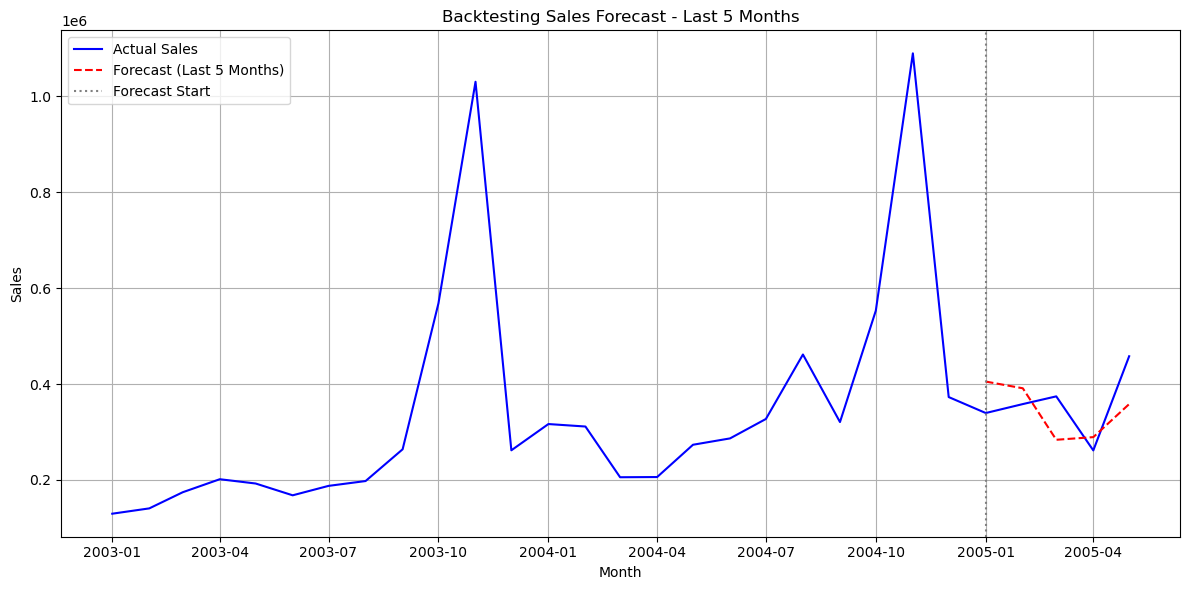

In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import numpy as np


# STEP 1: Load and clean your data
sales_data['Month'] = sales_data['ORDERDATE'].dt.to_period('M')
monthly_sales = sales_data.groupby('Month')['SALES'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

# STEP 2: Build the model
train = monthly_sales[:-5]
test = monthly_sales[-5:]

# Train Holt-Winters model
model = ExponentialSmoothing(
    train['SALES'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
fit = model.fit()

# Forecast next 5 months
forecast = fit.forecast(5)

# Evaluate performance
mae = mean_absolute_error(test['SALES'], forecast)
rmse = np.sqrt(mean_squared_error(test['SALES'], forecast))

print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Month'], monthly_sales['SALES'], label='Actual Sales', color='blue')
plt.plot(test['Month'], forecast, label='Forecast (Last 5 Months)', color='red', linestyle='--')
plt.axvline(x=test['Month'].iloc[0], color='gray', linestyle=':', label='Forecast Start')
plt.title('Backtesting Sales Forecast - Last 5 Months')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\lolal\AppData\Local\Temp\ipykernel_34300\104037669.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[col] = le.fit_transform(train_df[col])
C:\Users\lolal\AppData\Local\Temp\ipykernel_34300\104037669.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[col] = le.transform(test_df[col])


Improved XGBoost MAE: 356.83
Improved XGBoost RMSE: 642.83


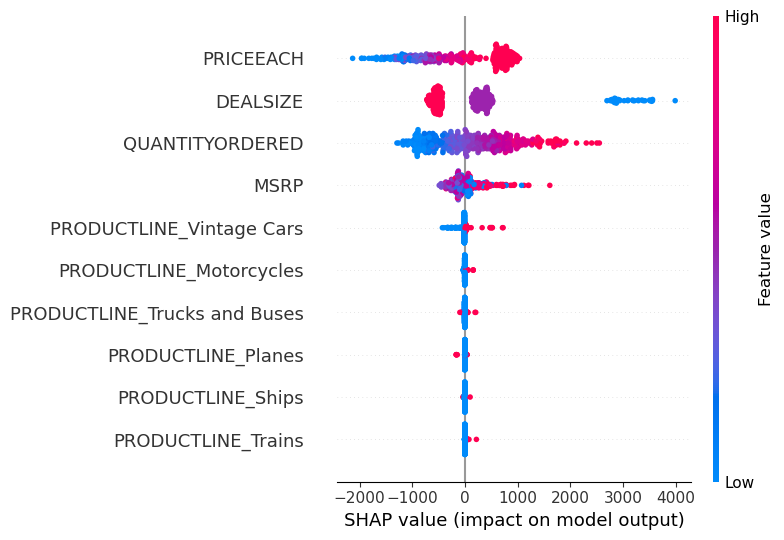

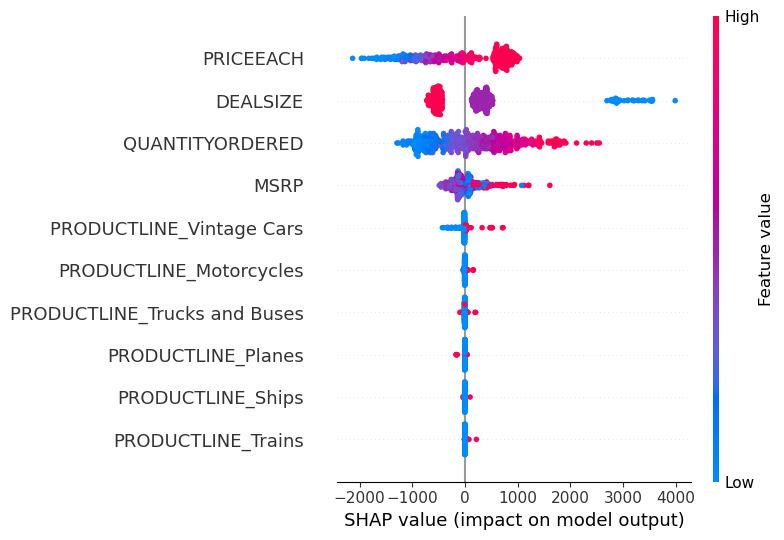

In [36]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

# Categorical and numerical features
categorical_cols = ['PRODUCTLINE']
label_encode_cols = ['DEALSIZE']
numerical_cols = ['PRICEEACH', 'QUANTITYORDERED', 'MSRP']

# Time-based train-test split
sales_data['YearMonth'] = sales_data['ORDERDATE'].dt.to_period('M')
last_5_months = sorted(sales_data['YearMonth'].unique())[-5:]
train_df = sales_data[~sales_data['YearMonth'].isin(last_5_months)]
test_df = sales_data[sales_data['YearMonth'].isin(last_5_months)]

# Target
target = 'SALES'

# Label encode 'DEALSIZE'
encoders = {}
for col in label_encode_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    encoders[col] = le

# ColumnTransformer with OneHotEncoder (sparse_output replaces sparse in new versions)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

# Fit on training data
X_train_raw = train_df[categorical_cols + numerical_cols]
X_test_raw = test_df[categorical_cols + numerical_cols]

preprocessor.fit(X_train_raw)
X_train_transformed = preprocessor.transform(X_train_raw)
X_test_transformed = preprocessor.transform(X_test_raw)

# Restore feature names after OneHotEncoding
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(encoded_cat_names) + numerical_cols

# Append label encoded features
X_train_final = np.hstack([X_train_transformed, train_df[label_encode_cols].values])
X_test_final = np.hstack([X_test_transformed, test_df[label_encode_cols].values])
all_feature_names += label_encode_cols

# Targets
y_train = train_df[target]
y_test = test_df[target]

# Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    objective='reg:squarederror'
)
model.fit(X_train_final, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Improved XGBoost MAE: {mae:.2f}")
print(f"Improved XGBoost RMSE: {rmse:.2f}")

# SHAP for model interpretation
explainer = shap.Explainer(model, X_train_final, feature_names=all_feature_names)
shap_values = explainer(X_test_final)

# Optional: SHAP summary plot (interpretable)
X_test_df = pd.DataFrame(X_test_final, columns=all_feature_names)
shap.summary_plot(shap_values, features=X_test_df, feature_names=all_feature_names)

# Save SHAP plot
shap.summary_plot(shap_values, features=X_test_df, feature_names=all_feature_names, show=False)
import matplotlib.pyplot as plt
plt.savefig("shap_summary_plot.png", bbox_inches='tight')


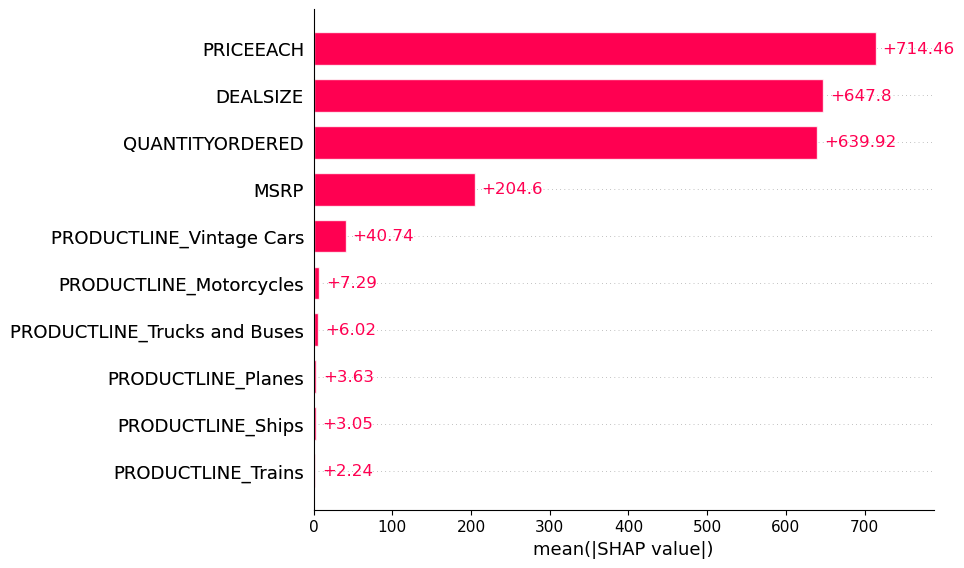

In [37]:
shap.plots.bar(shap_values)

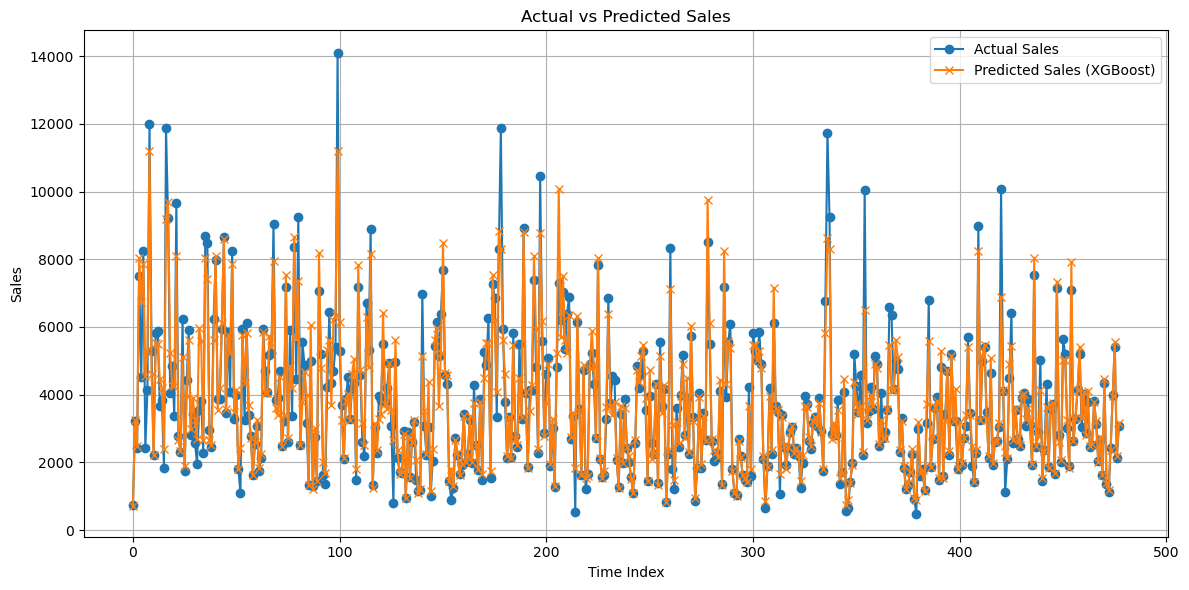

In [27]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Sales', marker='o')
plt.plot(y_pred, label='Predicted Sales (XGBoost)', marker='x')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
fig.savefig("Predicted vs Actual sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

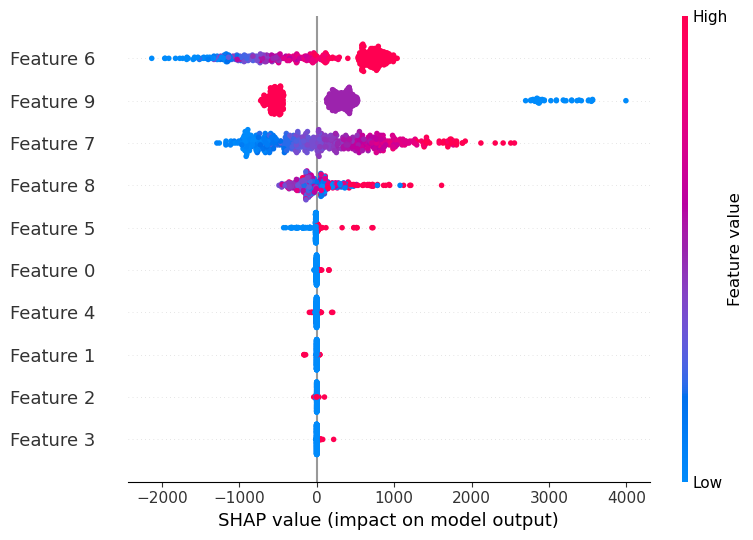

In [35]:
import shap

# Create TreeExplainer for XGBoost model
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

fig = plt.figure()
# Summary bar plot (feature importance)
shap.plots.bar(shap_values)
plt.tight_layout()
plt.savefig("shap_summary_features.png", dpi=300)  # Saves the plot as a high-resolution image
plt.close()

plt.figure()
# Summary dot plot (SHAP value spread)
shap.summary_plot(shap_values, X_test)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300)  # Saves the plot as a high-resolution image
plt.close()

In [26]:
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP_Value': shap_importance
}).sort_values(by='Mean_Abs_SHAP_Value', ascending=False)

# Print top features summary
print("Top Features by Mean Absolute SHAP Value:")
print(importance_df.head(10))

Top Features by Mean Absolute SHAP Value:
           Feature  Mean_Abs_SHAP_Value
1        PRICEEACH           671.632227
8         DEALSIZE           644.123142
0  QUANTITYORDERED           640.356634
3             MSRP           222.181769
7      PRODUCTLINE            48.126815
4         MONTH_ID            43.143219
2  ORDERLINENUMBER            29.509550
5          YEAR_ID            12.567722
6           QTR_ID             0.000000


In [26]:
drop_columns = ["ADDRESSLINE1", "ADDRESSLINE2", "ORDERNUMBER", "PHONE", "CONTACTLASTNAME", "CONTACTFIRSTNAME"]

sales_data.drop(columns = drop_columns, axis = 1, inplace = True)

What is the best year according to sales?

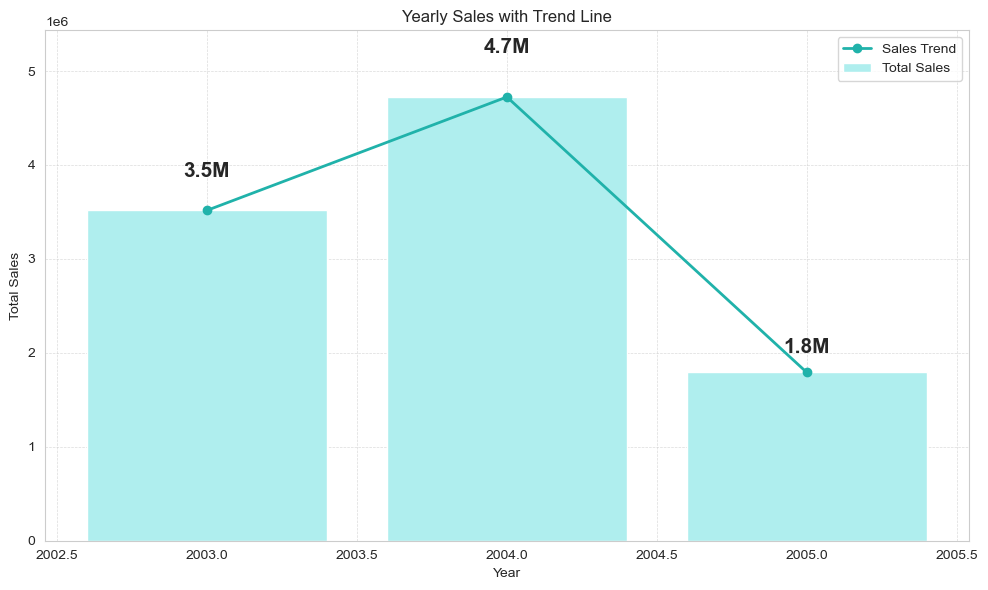

In [160]:
yearly_sales = sales_data.groupby('YEAR_ID')['SALES'].sum().reset_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart
bars = ax1.bar(yearly_sales['YEAR_ID'], yearly_sales['SALES'], color='paleturquoise', label='Total Sales')

# Line chart
ax1.plot(yearly_sales['YEAR_ID'], yearly_sales['SALES'], color='lightseagreen', marker='o', label='Sales Trend', linewidth=2)

# Calculate max height for y-axis limit
max_sales = yearly_sales['SALES'].max()
ax1.set_ylim(0, max_sales * 1.15)

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height* 1.09, f'{height/1e6:.1f}M', 
             ha='center', va='bottom', fontsize=15, fontweight='bold')

# Labels and title
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales')
ax1.set_title('Yearly Sales with Trend Line')
ax1.legend()

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
fig.savefig("Yearly Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:¶
1) In 2003, Sales were around 3.5 Million
2) In 2004, Sales were around 4.7 Million
3) In 2005, Sales were around 1.8 Million in just 5 months
4) Representing Progressive growth in the Sales

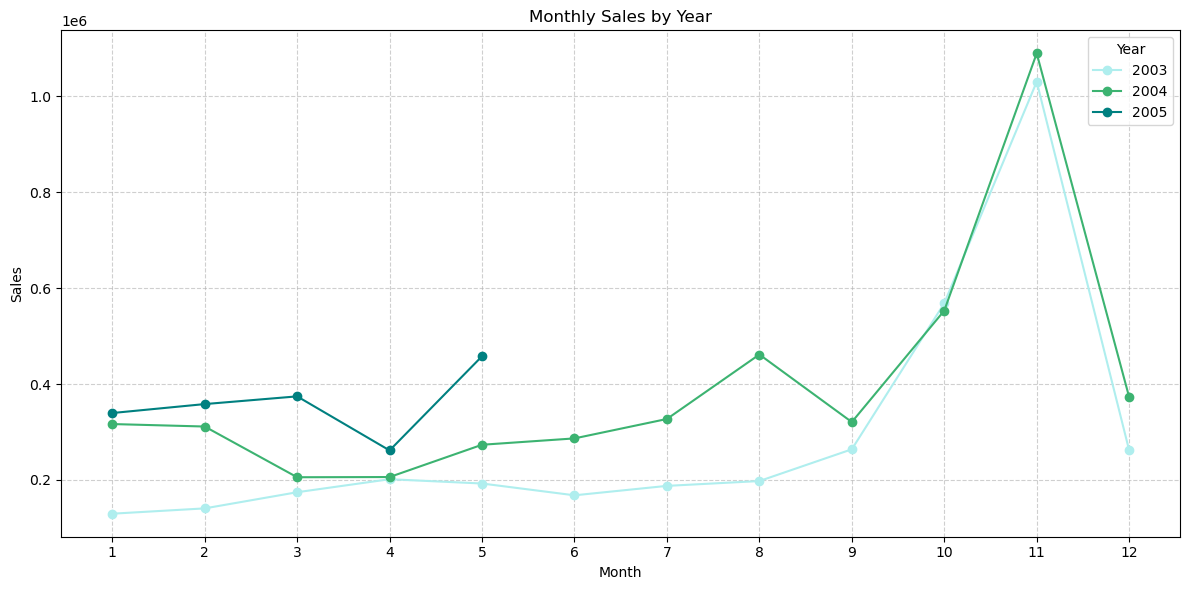

In [10]:
monthly_sales = sales_data.groupby(['YEAR_ID', 'MONTH_ID'])['SALES'].sum().reset_index()

# Pivot data to get months as X-axis and each year as a line
pivot_df = monthly_sales.pivot(index='MONTH_ID', columns='YEAR_ID', values='SALES')

# Plot
fig = plt.figure(figsize=(12, 6))

colors = {2003:'paleturquoise', 2004:'mediumseagreen', 2005:'teal'}

for year in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[year], marker='o', label=str(year), color=colors[year])

plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig("Monthly Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:
1) In 2003, month of May(5th) had the least amount of sales whereas month of July(7th) had best monthly sales
2) In 2004, month of April(4th) had the least amount of sales whereas month of May(5th) had best monthly sales
3) In 2005, month of January(1st) had the least amount of sales whereas month of April(4th) had best monthly sales
4) This shows that during the summer season sales are high and just before the summer season sales the least

## Which quarter is the best for each product line?

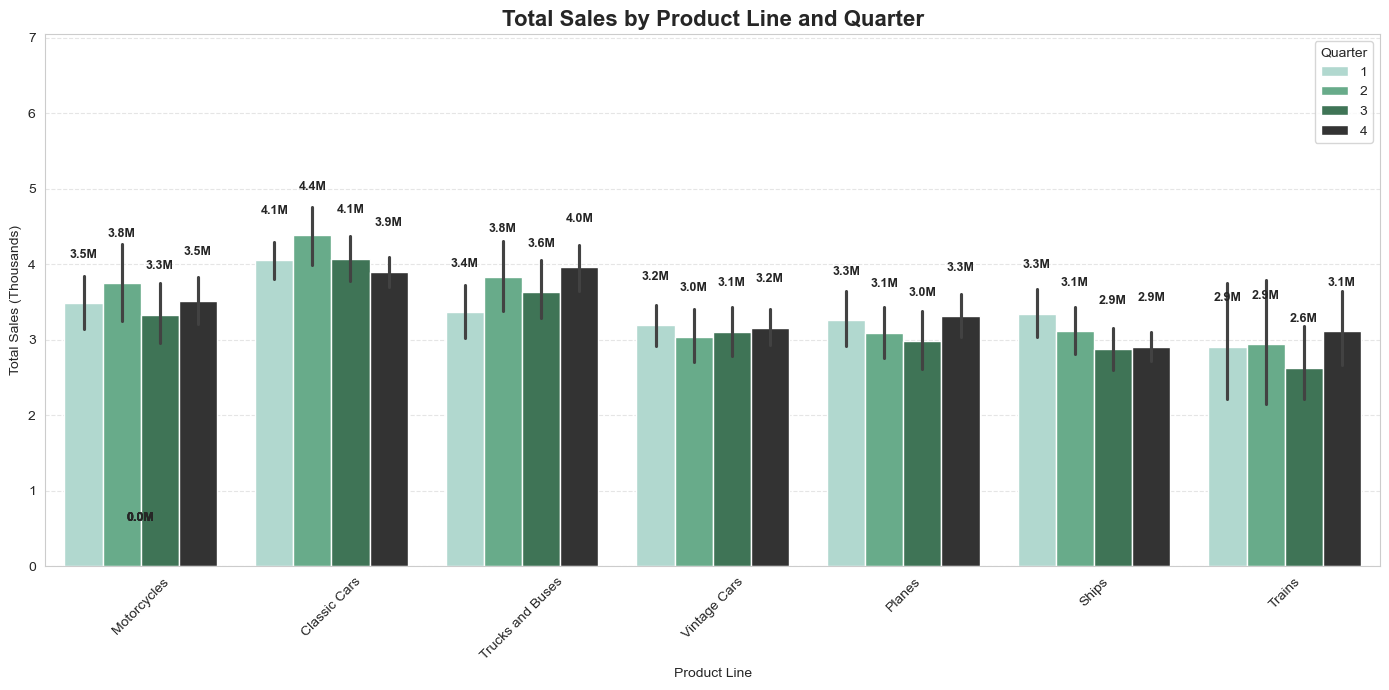

In [41]:
sales_data['Total Sales (K)'] = sales_data['SALES'] / 1_000
fig = plt.figure(figsize=(14, 7))

barplot = sns.barplot(
    data=sales_data,
    x='PRODUCTLINE',
    y='Total Sales (K)',
    hue='QTR_ID',    # Different quarters as hue
    palette='BuGn_d'
)

# Get max sales to scale y-axis and text placement
max_sales = sales_data['Total Sales (K)'].max()
plt.ylim(0, max_sales * 0.5)

# Add sales values on top of each bar
for bar in barplot.patches:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    value = y
    # Round to 1 decimal and add M
    label = f"{value:.1f}M"
    barplot.text(x, y + max_sales*0.04, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Total Sales by Product Line and Quarter', fontsize=16, fontweight='bold')
plt.ylabel('Total Sales (Thousands)')
plt.xlabel('Product Line')
plt.xticks(rotation=45)
plt.legend(title='Quarter', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
fig.savefig("ProductLine by Quarter Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:¶
In 4th quarter of the year all Products had maximum sales.
The reason may be arrival of the Chirstmas holidays.

What product sold the most? Why do you think it sold the most?

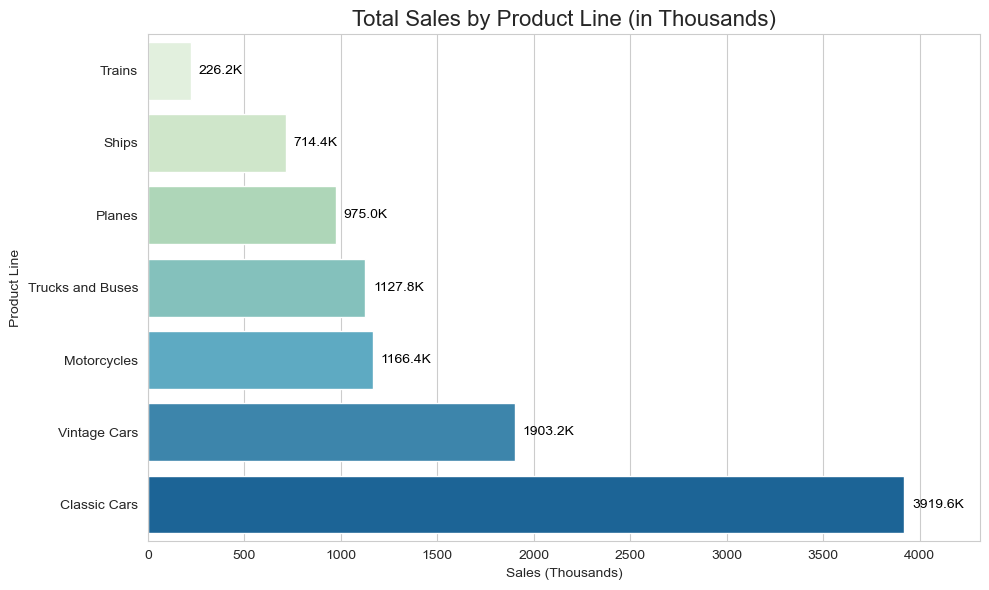

In [40]:
total_sales_by_product = sales_data.groupby('PRODUCTLINE')['SALES'].sum().sort_values()

# Convert sales to thousands for display
total_sales_k = total_sales_by_product / 1000

fig = plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Horizontal bar plot
ax = sns.barplot(x=total_sales_k.values, y=total_sales_k.index, palette="GnBu")

# Add sales values on bars
for i, v in enumerate(total_sales_k.values):
    ax.text(v + max(total_sales_k.values)*0.01, i, f"{v:.1f}K", color='black', va='center')


plt.title("Total Sales by Product Line (in Thousands)", fontsize=16)
plt.xlabel("Sales (Thousands)")
plt.ylabel("Product Line")
plt.xlim(0, max(total_sales_k.values) * 1.1)
plt.tight_layout()
fig.savefig("ProductLine Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:
The above graph shows that the products with the lowest price were sold the most, whereas the products with a high price were the least popular.

Why did it sell the most?
Reasons might include:

Popularity / Demand: That product line might be more popular or in higher demand.

Price & Value: It could be priced competitively or offer better value.

Seasonality: Maybe certain products sell more during specific quarters or months.

Marketing: More promotional efforts or visibility.

Product Variety: More product options or variants under that line.

Target Market: Stronger presence or better fit in key markets.

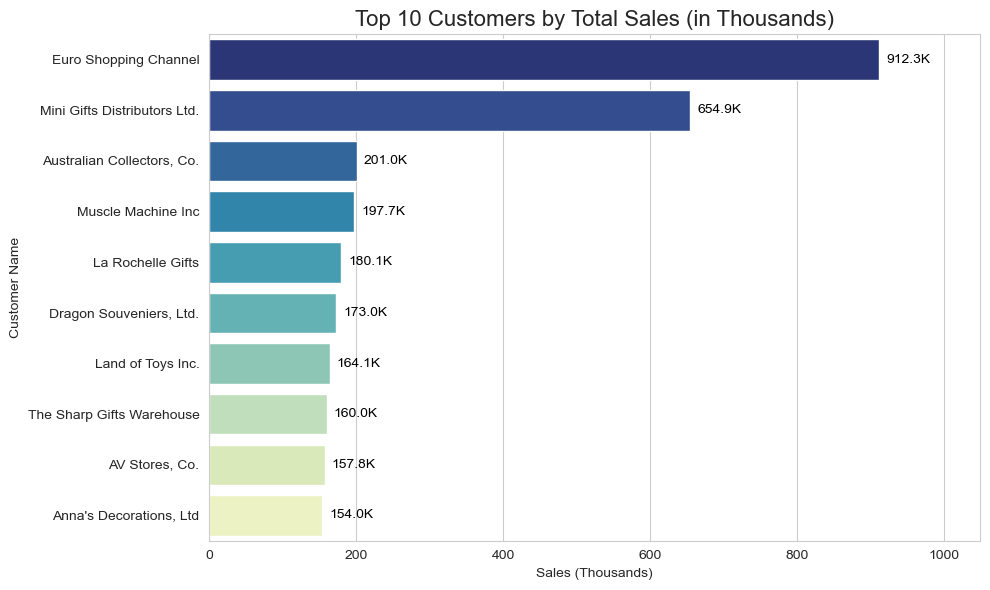

In [51]:
top_customers = sales_data.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10)

# Convert to thousands for display
top_customers_k = top_customers / 1000

# Set style
fig = plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create barplot
ax = sns.barplot(x=top_customers_k.values, y=top_customers_k.index, palette="YlGnBu_r")

# Annotate bars with values
for i, v in enumerate(top_customers_k.values):
    ax.text(v + max(top_customers_k.values)*0.01, i, f"{v:.1f}K", va='center', color='black')

plt.xlim(0, max(top_customers_k.values) * 1.15)

plt.title("Top 10 Customers by Total Sales (in Thousands)", fontsize=16)
plt.xlabel("Sales (Thousands)")
plt.ylabel("Customer Name")
plt.tight_layout()
fig.savefig("Top Customer Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:
Clearly the Euro Shopping Channel was the top customer buying the most products

## Which country has the best sales?

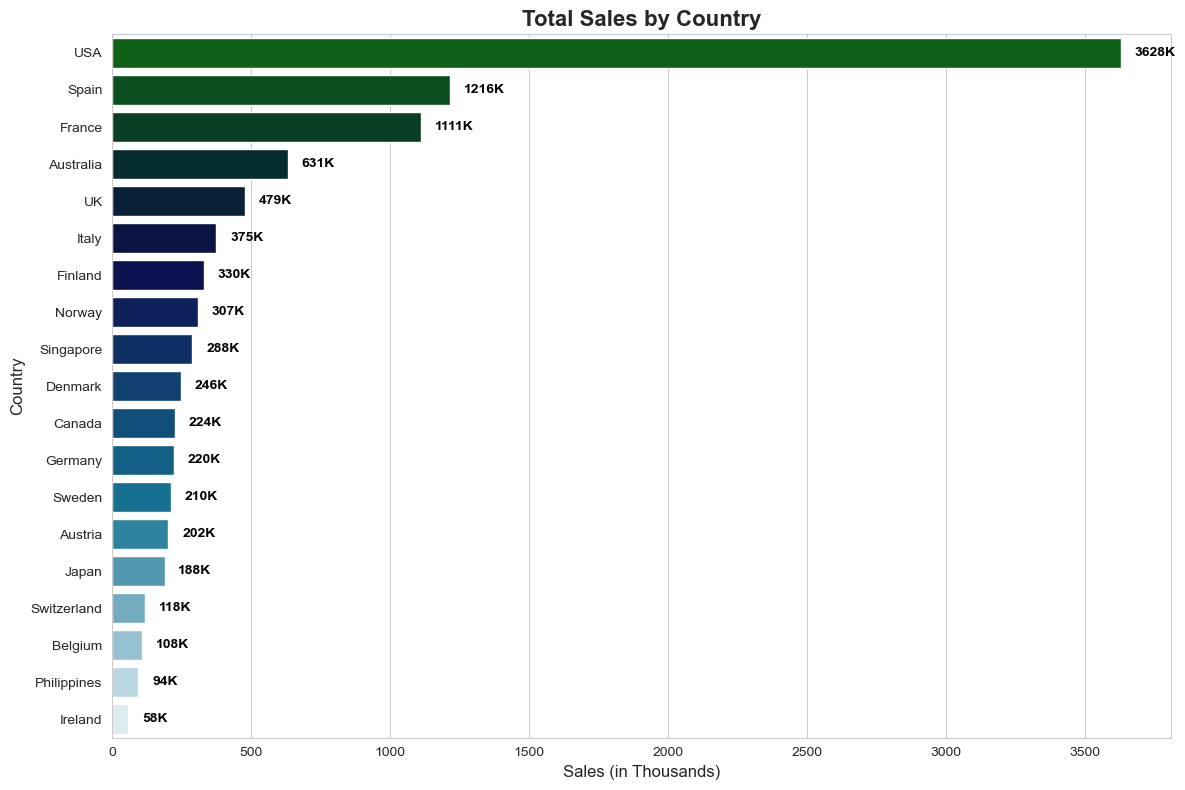

In [57]:
country_sales = sales_data.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False) / 1000  # in 'K'

# Set style
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plot horizontal bar chart
ax = sns.barplot(x=country_sales.values, y=country_sales.index, palette='ocean')

# Add value labels to bars
for i, v in enumerate(country_sales.values):
    ax.text(v + 50, i, f'{v:.0f}K', color='black', va='center', fontweight='bold')

# Titles and labels
plt.title('Total Sales by Country', fontsize=16, fontweight='bold')
plt.xlabel('Sales (in Thousands)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
fig.savefig("Top Country Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:
USA had the best sales in the world followed by Spain and France.

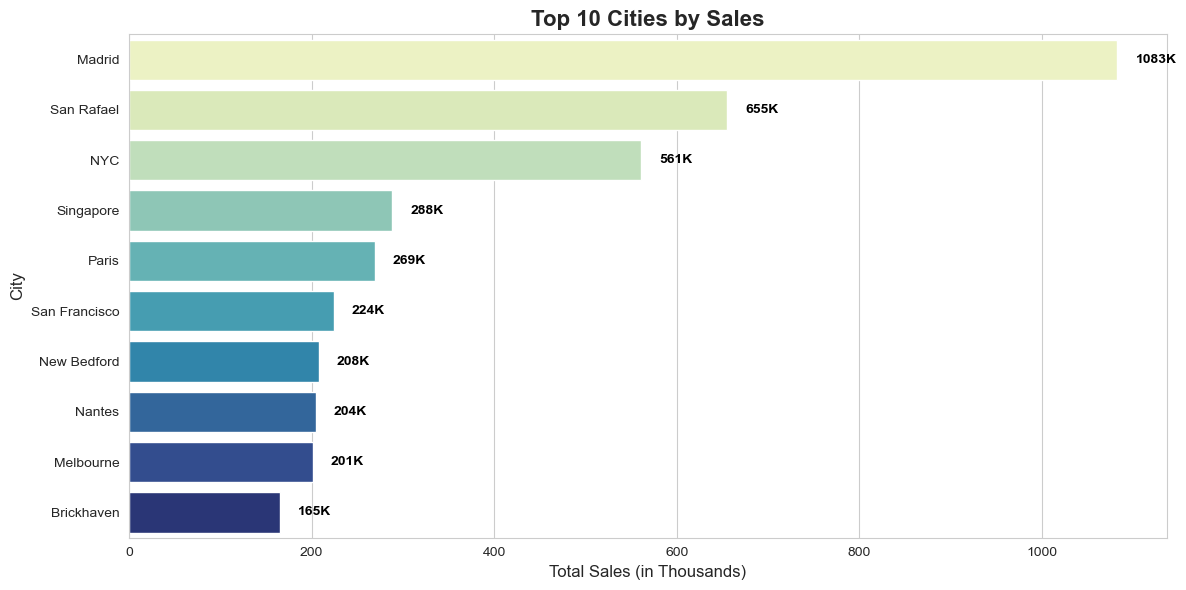

In [60]:
top_city_sales = sales_data.groupby('CITY')['SALES'].sum().sort_values(ascending=False)
top_city = top_city_sales.idxmax()
top_sales = top_city_sales.max()
top_cities = top_city_sales.head(10) / 1000  # Convert to K

fig = plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=top_cities.values, y=top_cities.index, palette='YlGnBu')

# Add value labels
for i, v in enumerate(top_cities.values):
    ax.text(v + 20, i, f'{v:.0f}K', color='black', va='center', fontweight='bold')

plt.title('Top 10 Cities by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (in Thousands)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
fig.savefig("Top City Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:¶
City of Madrid had the best sales in the world followed by San Rafael and New York City.

Why did the top city perform well?
You can analyze the reason using:

Customer concentration: Count of customers from that city.

Product preference: High-value product lines popular in that city.

Deal size: Cities with higher “Large” deal sizes.

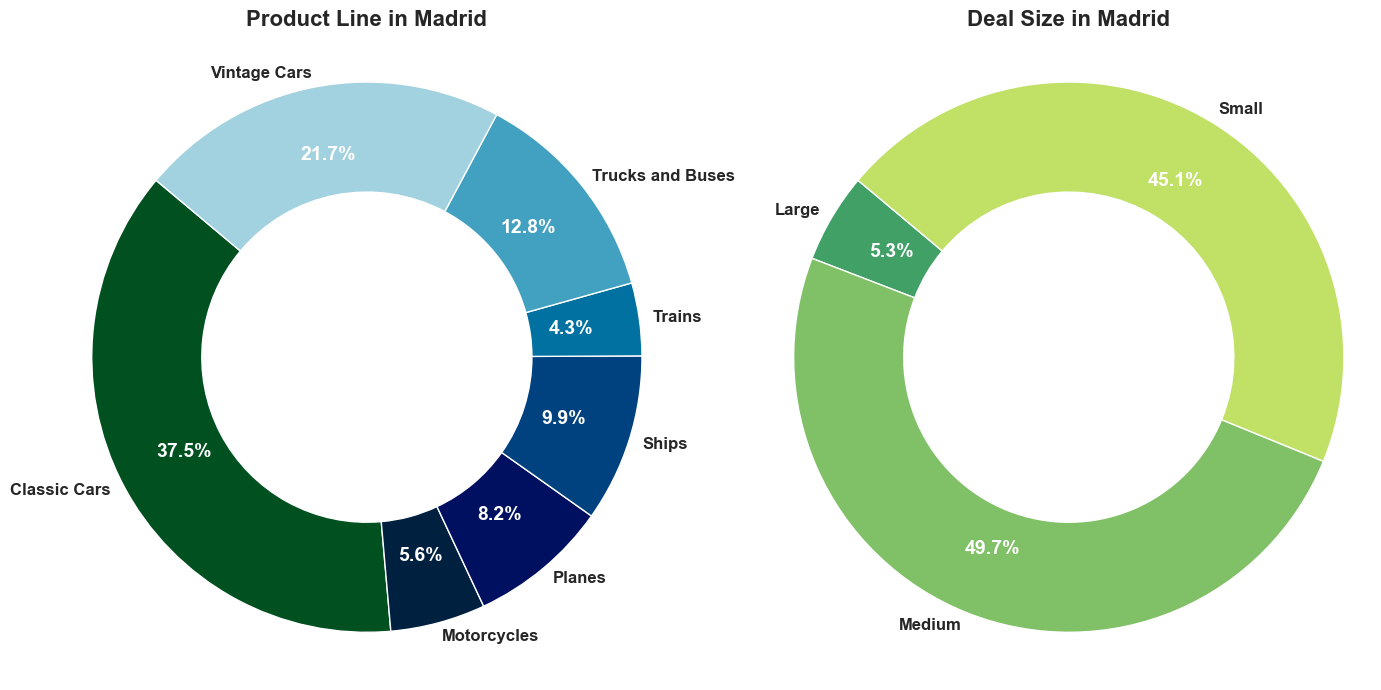

In [82]:
madrid_data = sales_data[sales_data['CITY'] == 'Madrid']

# Counts
product_counts = madrid_data['PRODUCTLINE'].value_counts().sort_index()
deal_size_counts = madrid_data['DEALSIZE'].value_counts().sort_index()

# Colors
product_colors = sns.color_palette("ocean", len(product_counts))
deal_colors = sns.color_palette("summer", len(deal_size_counts))

fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# --- Product Line Donut ---
wedges1, texts1 = axs[0].pie(
    product_counts.values,
    labels=None,
    colors=product_colors,
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor='white')
)
axs[0].set_title("Product Line in Madrid", fontsize=16, fontweight='bold')
axs[0].axis('equal')

# Add category labels OUTSIDE near slices
for i, p in enumerate(wedges1):
    ang = (p.theta2 + p.theta1) / 2.
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    horizontalalignment = 'left' if x > 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    axs[0].annotate(
        product_counts.index[i],
        xy=(x*1.05, y*1.05),
        ha=horizontalalignment,
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Add percentage inside the ring, slightly towards center
    pct = product_counts.values[i] / product_counts.sum() * 100
    axs[0].text(
        x*0.75, y*0.75,
        f"{pct:.1f}%",
        ha='center', va='center',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

# --- Deal Size Donut ---
wedges2, texts2 = axs[1].pie(
    deal_size_counts.values,
    labels=None,
    colors=deal_colors,
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor='white')
)
axs[1].set_title("Deal Size in Madrid", fontsize=16, fontweight='bold')
axs[1].axis('equal')

# Add category labels OUTSIDE near slices
for i, p in enumerate(wedges2):
    ang = (p.theta2 + p.theta1) / 2.
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    horizontalalignment = 'left' if x > 0 else 'right'
    axs[1].annotate(
        deal_size_counts.index[i],
        xy=(x*1.05, y*1.05),
        ha=horizontalalignment,
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Add percentage inside the ring, slightly towards center
    pct = deal_size_counts.values[i] / deal_size_counts.sum() * 100
    axs[1].text(
        x*0.75, y*0.75,
        f"{pct:.1f}%",
        ha='center', va='center',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

plt.tight_layout()
fig.savefig("Madrid_SideBySide_Donuts_PercentOutsideLabels_InsidePercent.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Is there a relationship between deal size and sales?

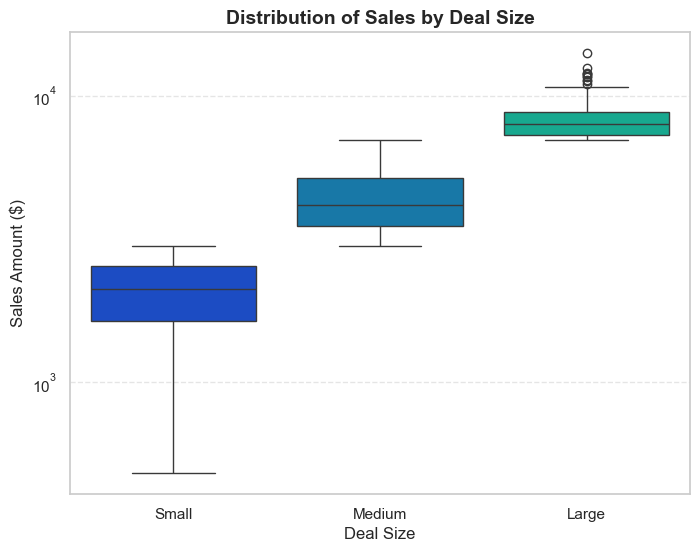

In [206]:
deal_sales = sales_data.groupby('DEALSIZE')['SALES'].agg(['count', 'mean', 'sum']).reset_index().sort_values(by='sum', ascending=False)

fig = plt.figure(figsize=(8, 6))
sns.boxplot(data=sales_data, x='DEALSIZE', y='SALES', palette='winter')
plt.title('Distribution of Sales by Deal Size', fontsize=14, fontweight='bold')
plt.ylabel('Sales Amount ($)')
plt.xlabel('Deal Size')
plt.yscale('log')  # Optional: use log scale to handle skewed data
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
fig.savefig("Deal Size sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

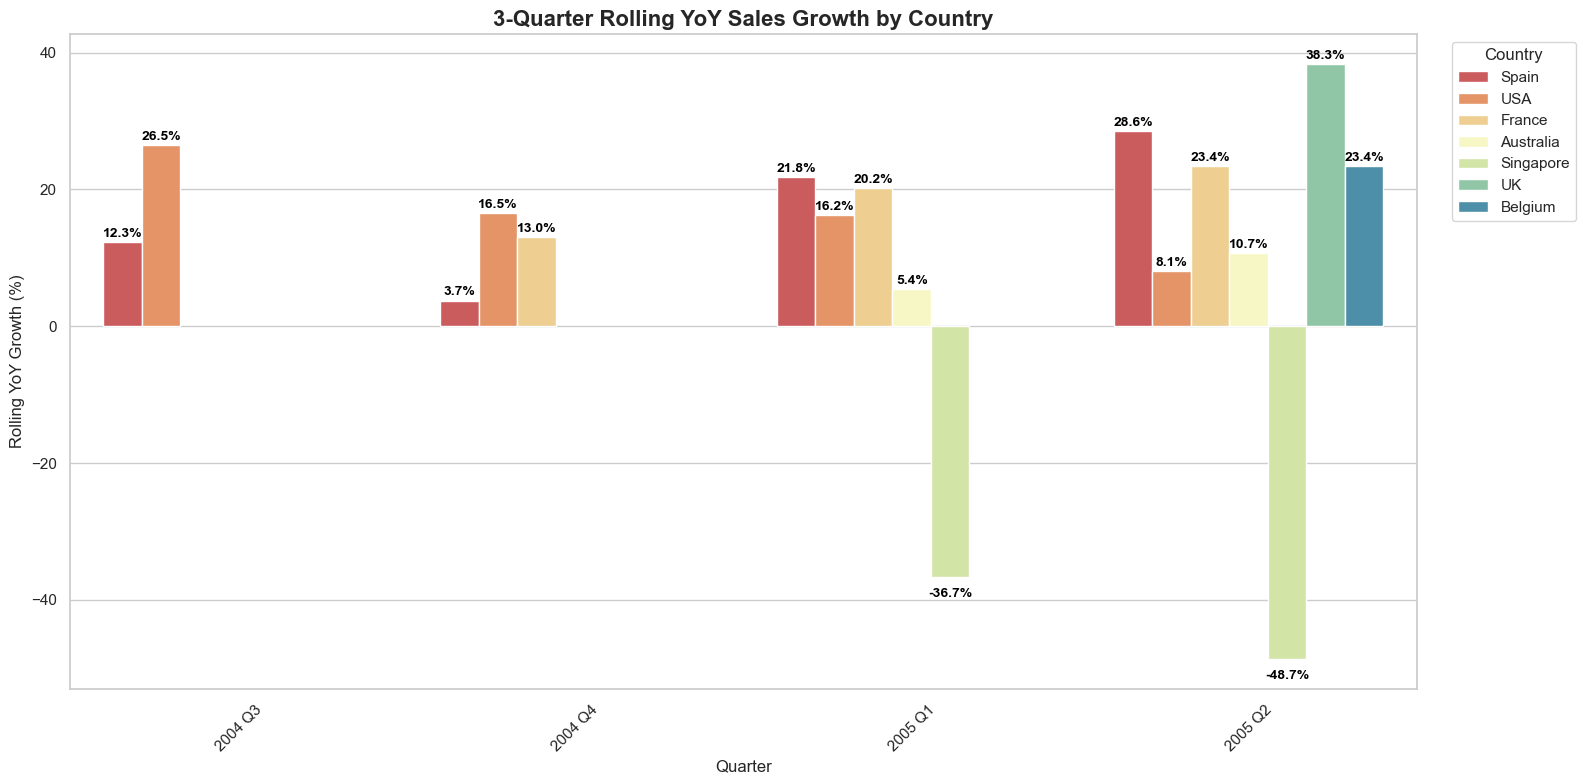

In [139]:
# Create a datetime column for proper chronological sorting
quarterly_sales['quarter_date'] = pd.to_datetime(
    quarterly_sales['YEAR_ID'].astype(str) + '-Q' + quarterly_sales['QTR_ID'].astype(str)
)

# Create label like "2003 Q1"
quarterly_sales['quarter_label'] = quarterly_sales['YEAR_ID'].astype(str) + ' Q' + quarterly_sales['QTR_ID'].astype(str)

# Drop NaN growth values
plot_data = quarterly_sales.dropna(subset=['rolling_YoY_growth'])

# Sort by date
plot_data = plot_data.sort_values('quarter_date')

# Plot
fig = plt.figure(figsize=(16, 8))
sns.set(style="whitegrid")

# Barplot
ax = sns.barplot(
    data=plot_data,
    x='quarter_label',
    y='rolling_YoY_growth',
    hue='COUNTRY',
    palette='Spectral'
)

# Annotate values on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.annotate(f"{height:.1f}%", 
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 6 if height > 0 else -12), 
                        textcoords="offset points",
                        ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='black')

# Final formatting
plt.title('3-Quarter Rolling YoY Sales Growth by Country', fontsize=16, fontweight='bold')
plt.ylabel('Rolling YoY Growth (%)')
plt.xlabel('Quarter')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig("3-Quarter Rolling YoY Sales Growth sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [210]:
quarterly_sales.describe()

,YEAR_ID,QTR_ID,SALES,quarter_start,rolling_sales,rolling_sales_lag4,rolling_YoY_growth,quarter_date
count,111.000000,111.000000,111.000000,111,5.600000e+01,1.700000e+01,17.000000,111
mean,2003.846847,2.468468,90384.043694,2004-03-18 19:40:32.432432384,4.493439e+05,6.138112e+05,10.746697,2004-03-18 19:40:32.432432384
min,2003.000000,1.000000,553.950000,2003-01-01 00:00:00,6.990903e+04,6.990903e+04,-48.664789,2003-01-01 00:00:00
25%,2003.000000,1.000000,38410.265000,2003-10-01 00:00:00,1.874019e+05,2.962681e+05,8.083932,2003-10-01 00:00:00
50%,2004.000000,2.000000,53631.960000,2004-04-01 00:00:00,3.006155e+05,4.431308e+05,16.200141,2004-04-01 00:00:00
75%,2004.000000,4.000000,100150.680000,2004-10-01 00:00:00,4.816068e+05,4.912108e+05,23.394746,2004-10-01 00:00:00
max,2005.000000,4.000000,739301.850000,2005-04-01 00:00:00,1.842737e+06,1.650720e+06,38.299987,2005-04-01 00:00:00
std,0.728613,1.158524,115742.127507,NaN,4.704625e+05,5.234624e+05,22.068376,NaN


## Territory & Customer Behavior – Geography Matters
### Insight: Insight: Which territories generate high total sales? Which ones have high-value customers?

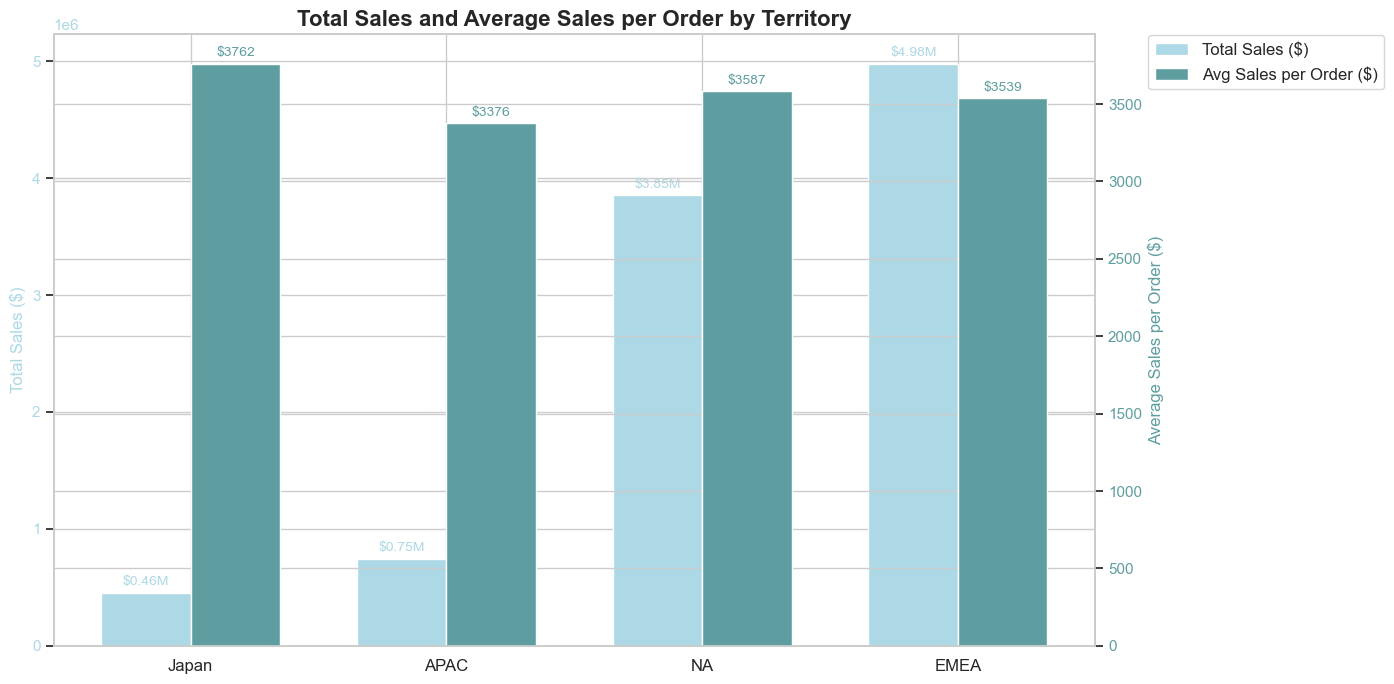

In [194]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample data (replace with your actual data variables)
territories = ['Japan', 'APAC', 'NA', 'EMEA']
total_sales = [455173.22, 746121.83, 3852061.39, 4979272.41]   # total sales
avg_sales = [3761.76, 3376.12, 3586.65, 3538.93]               # average sales per order

# Create dataframe for convenience
df = pd.DataFrame({
    'Territory': territories,
    'Total Sales': total_sales,
    'Average Sales per Order': avg_sales
})

x = np.arange(len(df['Territory']))  # label locations
width = 0.35  # width of bars

fig, ax1 = plt.subplots(figsize=(14, 7))  # Increased figure size

# Bar plot for total sales (left y-axis)
bars1 = ax1.bar(x - width/2, df['Total Sales'], width, label='Total Sales ($)', color='lightblue')
ax1.set_ylabel('Total Sales ($)', color='lightblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='lightblue')
ax1.set_xticks(x)
ax1.set_xticklabels(df['Territory'], fontsize=12)
ax1.set_title('Total Sales and Average Sales per Order by Territory', fontsize=16, fontweight='bold')

# Add value labels for total sales bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f"${height/1e6:.2f}M",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0,3),
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=10, color='lightblue')

# Create second y-axis for average sales
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df['Average Sales per Order'], width, label='Avg Sales per Order ($)', color='cadetblue')
ax2.set_ylabel('Average Sales per Order ($)', color='cadetblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='cadetblue')

# Add value labels for average sales bars
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f"${height:.0f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0,3),
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=10, color='cadetblue')

# Legends outside the plot area on the right
fig.legend(loc='center left', bbox_to_anchor=(0.82, 0.9), fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make room for legend
fig.savefig("Total Sales and Average Sales per Order by Territory.jpg", dpi=300, bbox_inches='tight')
plt.show()


Territory Sales Performance Insight
1. Total Sales Perspective:
EMEA ($4.98M) and NA ($3.85M) dominate total revenue, significantly outperforming APAC ($746K) and Japan ($455K). These regions are likely supported by broader product demand or more consistent customer bases.

2. Average Sales per Order Perspective:
While Japan contributes the least total revenue, it has the highest average sales per order ($3,761.76). This suggests that Japan’s customers place fewer but higher-value orders—a sign of a premium or niche market segment.

NA and EMEA are very close in average order value (~$3,500), indicating similar sales behaviors and pricing effectiveness.

APAC shows both low total sales and lowest average order size ($3,376.12), possibly indicating a price-sensitive or developing market.



- Key Insights & Recommendations:
- Territory	Total Sales Rank	Avg Order Value Rank	Opportunity
- EMEA	🥇 Highest	🥉 Mid-High	Maintain lead; expand customer base.
- NA	🥈 Strong	🥈 Strong	Consider premium product upselling.
- Japan	🟡 Lowest	🥇 Highest	Target high-end buyers with exclusive offerings.
- APAC	🔻 Low	🔻 Lowest	Explore pricing strategies or localized marketing to grow.

#### Insight: Larger deals contribute more on average—are they worth targeting more?

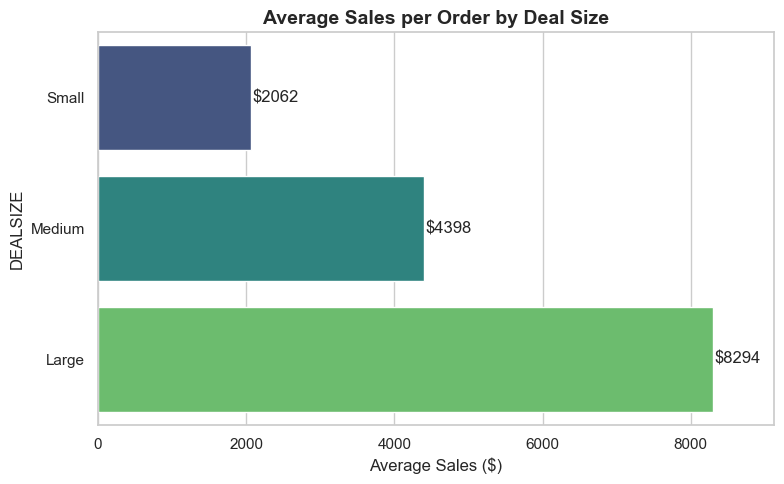

In [195]:
avg_sales_by_dealsize = sales_data.groupby('DEALSIZE')['SALES'].mean().sort_values()

fig = plt.figure(figsize=(8, 5))
sns.barplot(x=avg_sales_by_dealsize.values, y=avg_sales_by_dealsize.index, palette='viridis')
plt.title("Average Sales per Order by Deal Size", fontsize=14, fontweight='bold')
plt.xlim(0, max(avg_sales_by_dealsize.values) * 1.1)
plt.xlabel("Average Sales ($)")
for i, v in enumerate(avg_sales_by_dealsize.values):
    plt.text(v + 20, i, f"${v:.0f}", va='center')
plt.tight_layout()
fig.savefig("Average Sales per Order by Deal Size.jpg", dpi=300, bbox_inches='tight')
plt.show()

While larger deal sizes yield higher revenue per transaction, some medium-size deals also show high sales when paired with large order quantities. Sales teams could prioritize mid-size deals with high volume potential.

## Product Line Performance – Not All Products Sell Equally
### Insight: Which products are best-sellers by revenue and by volume?

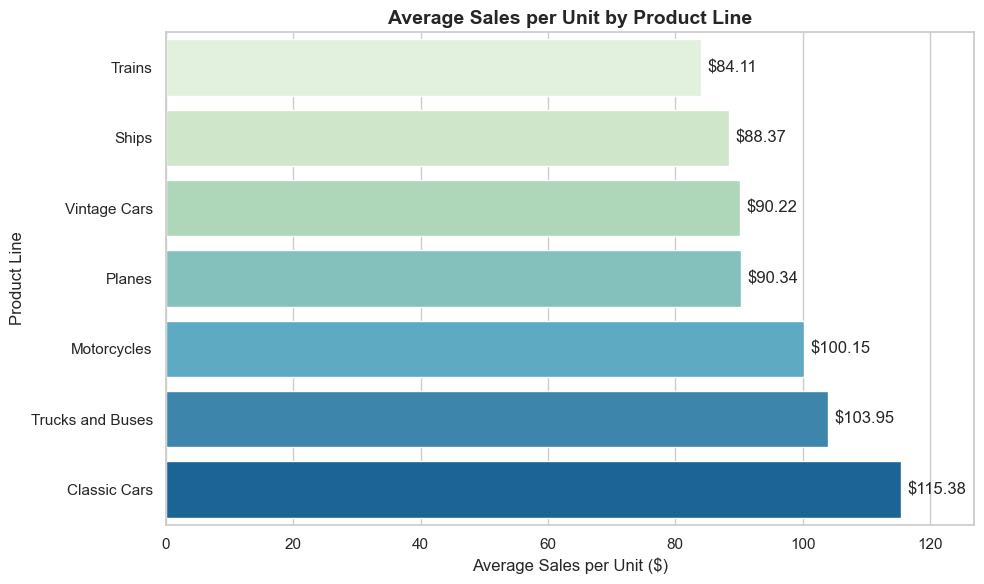

In [156]:
# Create a new column for Sales per Unit
sales_data['SALES_PER_UNIT'] = sales_data['SALES'] / sales_data['QUANTITYORDERED']

# Group by Product Line and take the average sales per unit
avg_sales_per_unit = sales_data.groupby('PRODUCTLINE')['SALES_PER_UNIT'].mean().sort_values()

# Plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=avg_sales_per_unit.values, y=avg_sales_per_unit.index, palette='GnBu')

# Annotate values
for i, v in enumerate(avg_sales_per_unit.values):
    plt.text(v + 1, i, f"${v:.2f}", va='center')

plt.title("Average Sales per Unit by Product Line", fontsize=14, fontweight='bold')
plt.xlabel("Average Sales per Unit ($)")
plt.xlim(0, max(avg_sales_per_unit.values) * 1.1)
plt.ylabel("Product Line")
plt.tight_layout()
fig.savefig("Average Sales per Unit by Product Line.jpg", dpi=300, bbox_inches='tight')
plt.show()

Classic Cars have the highest sales per unit ($115.38), indicating they are the most premium and potentially high-margin products in the catalog. These items likely appeal to niche collectors or affluent customers and should be prioritized in premium marketing campaigns and strategic upselling.

On the other end, Trains ($84.11) and Ships ($88.37) generate the lowest revenue per unit, suggesting they may either be lower-priced items or frequently discounted. These could be targeted in volume-based promotions or bundled offers to boost total revenue.

Notably, Motorcycles ($100.15) and Trucks and Buses ($103.95) fall into the mid-to-high margin range, making them solid candidates for both volume and margin-focused strategies.


Recommendations:
Double down on promoting Classic Cars through premium channels or limited-edition campaigns.

Reposition or bundle lower-margin lines like Trains to improve profitability.

Monitor mid-range products (e.g., Motorcycles) for upsell opportunities where customer demand is strong.

Deal Size Frequency

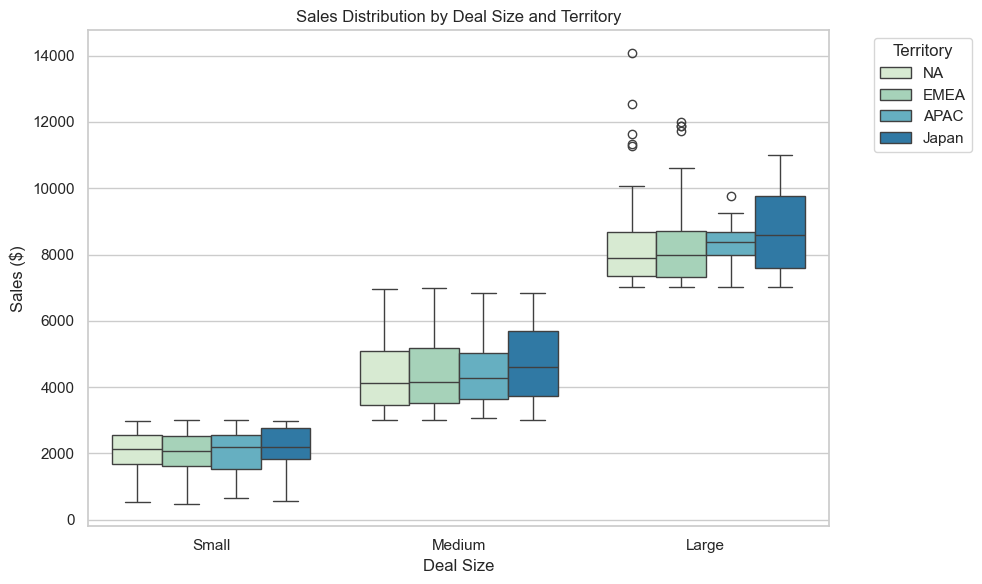

In [146]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=sales_data, x='DEALSIZE', y='SALES', hue='TERRITORY', palette='GnBu')
plt.title('Sales Distribution by Deal Size and Territory')
plt.xlabel('Deal Size')
plt.ylabel('Sales ($)')
plt.legend(title='Territory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
fig.savefig("Deal Size by territory sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Summary of Key Patterns & Trends:
Seasonality: Certain product lines show sales spikes in specific quarters.

Deal Size Impact: Larger deals yield higher sales but are less frequent.

Customer Concentration: A few top customers contribute a significant portion of total sales.

Territorial Variation: Sales and deal sizes vary significantly by territory.

Pricing & Sales Relationship: Price per item and MSRP strongly influence total sales.

## Performance Analysis

Analyze factors that drive sales success
Evaluate relationships between variables (e.g. deal size, quantity ordered, sales performance)
Identify any correlations that could inform decision-making

Correlation Matrix

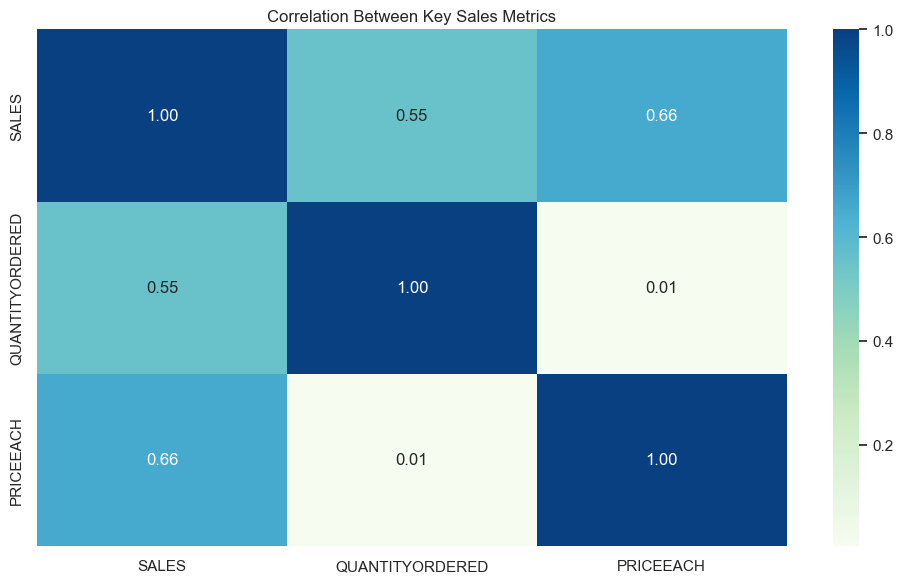

In [200]:
fig = plt.figure(figsize=(10, 6))
sns.heatmap(sales_data[['SALES', 'QUANTITYORDERED', 'PRICEEACH']].corr(), 
            annot=True, cmap='GnBu', fmt='.2f')
plt.title('Correlation Between Key Sales Metrics')
plt.tight_layout()
fig.savefig("correlation key metrics.jpg", dpi=300, bbox_inches='tight')
plt.show()

Observations:

Strong positive correlation between QUANTITYORDERED and SALES.

Moderate correlation between PRICEEACH and SALES.

MSRP has limited correlation with actual sales—possibly due to discounts or pricing strategy.


Identify correlations for decision-making
Insights:

Focus marketing efforts on high-performing product lines and encourage higher quantity orders.

Deal size segmentation can help tailor strategies:

Small deals → Cross-sell or bundle.

Medium/large deals → Loyalty programs or volume discounts.

Country and city analysis shows territorial strategy matters; align inventory and promotion efforts accordingly.



## Quantity Ordered vs Sales (Colored by Deal Size)
### Insight: Are higher quantity orders driving higher sales? Does this differ by deal size?

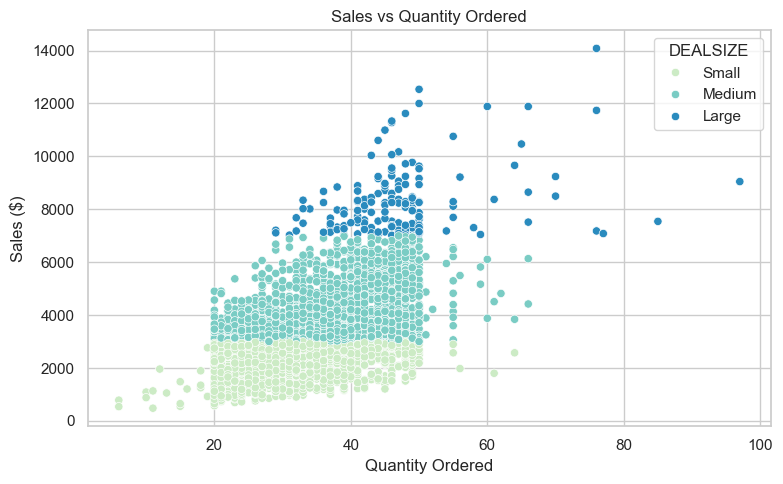

In [197]:
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=sales_data, x='QUANTITYORDERED', y='SALES', hue='DEALSIZE', palette='GnBu')
plt.title('Sales vs Quantity Ordered')
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales ($)')
plt.tight_layout()
fig.savefig("Quantity Ordered vs Sales.jpg", dpi=300, bbox_inches='tight')
plt.show()

Key Takeaways
Clear Upward Trend:

As deal size increases, both quantity ordered and total sales increase.

Large deals bring nearly 4× revenue compared to small ones.

High Value per Unit:

Sales per unit also rise with deal size (from ~$68 to ~$176), suggesting larger deals are not just bulkier, but also higher value per item.

Strategic Customer Segments:

Large deal customers are your most profitable segment, not just due to volume, but also better pricing or higher-end products.



Recommendations
🎯 Target More Large Deals: Focus marketing and relationship efforts on customers capable of large deal sizes. Consider loyalty incentives for them.

💸 Bundle to Upsell Medium Deals: Since medium deals are closer to large in quantity but lower in per-unit value, bundle premium products or add-on services to lift per-unit revenue.

📉 Re-evaluate Small Deals: These drive the least revenue per unit. Investigate:

Are these loss leaders?

Can they be automated or migrated to self-service channels?

Is there potential to convert small deal clients into larger ones?

📦 Inventory Planning: The clear volume stratification by deal size helps in demand forecasting and stock allocation per segment.


Key Findings:

Deal Size and Sales: Larger deal sizes tend to correlate with higher average sales values.

Quantity Ordered and Sales: Sales increase linearly with quantity ordered, showing that bulk orders significantly contribute to higher revenue.

Product Line Impact: Certain product lines (like Classic Cars and Vintage Cars) dominate sales—indicating product category plays a key role in driving success.

## Customer segmentation
If Your Goal Is Customer Segmentation (Understanding Behaviors, Targeting, Loyalty):
→ Use 1 row per unique customer (e.g., via aggregation like RFM or behavioral averages)

Why?

You want to group similar customers, not individual transactions.

You don’t want customers with more transactions to unfairly dominate the model.

RFM-based features + average metrics (spend, quantity, frequency) provide a cleaner customer-level profile.

🧠 You did this already when aggregating by CUSTOMERNAME and computing:

Recency

Frequency

Monetary

Avg price, total sales, etc.

✅ This is the recommended approach for most business/customer segmentation.



In [202]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Copy original data
df = sales_data.copy()

# 2. Ensure ORDERDATE is datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# 3. Calculate RFM
snapshot_date = df['ORDERDATE'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CUSTOMERNAME').agg({
    'ORDERDATE': lambda x: (snapshot_date - x.max()).days,  # Recency
    'ORDERNUMBER': 'nunique',                                # Frequency
    'SALES': 'sum'                                            # Monetary
}).reset_index()
rfm.columns = ['CUSTOMERNAME', 'Recency', 'Frequency', 'Monetary']

# 4. Merge RFM back with sales_data on CUSTOMERNAME
merged = pd.merge(df, rfm, on='CUSTOMERNAME')

# 5. Select features
features = ['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
            'PRODUCTLINE', 'MSRP', 'TERRITORY', 'DEALSIZE',
            'Recency', 'Frequency', 'Monetary']

data_for_clustering = merged[features].copy()

# 6. Handle categorical features
categorical = ['PRODUCTLINE', 'TERRITORY', 'DEALSIZE']
numerical = [col for col in data_for_clustering.columns if col not in categorical]

# 7. Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(sparse_output=False), categorical)
])

# 8. Transform the data
processed_data = preprocessor.fit_transform(data_for_clustering)

# 9. Elbow method to determine best k
inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(processed_data)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(processed_data, kmeans.labels_))

# 10. Apply KMeans with optimal k
optimal_k = 4  # or based on plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(processed_data)

# 11. Attach cluster labels to original data
merged['Segment'] = cluster_labels

def mode(series):
    return series.mode().iloc[0] if not series.mode().empty else np.nan

# 12. Summarize clusters
summary = merged.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'SALES': 'mean',
    'QUANTITYORDERED': 'mean',
    'PRICEEACH': 'mean',
    'MSRP': 'mean',
    'PRODUCTLINE': mode, 
    'TERRITORY': mode, 
    'DEALSIZE': mode
}).round(2)

print("\n📊 Cluster Summary:\n")
print(summary)

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



📊 Cluster Summary:

         Recency  Frequency   Monetary    SALES  QUANTITYORDERED  PRICEEACH  \
Segment                                                                       
0           1.78      22.48  811742.62  3598.83            35.86      83.44   
1         158.17       3.28  113494.66  3989.36            36.98      90.06   
2         163.76       3.27  115259.97  1954.66            30.87      64.95   
3         174.02       3.15  111598.95  4747.52            37.27      96.86   

           MSRP   PRODUCTLINE TERRITORY DEALSIZE  
Segment                                           
0        100.06  Classic Cars      EMEA   Medium  
1        108.68  Classic Cars      EMEA   Medium  
2         68.94  Vintage Cars      EMEA    Small  
3        125.83  Classic Cars      EMEA   Medium  


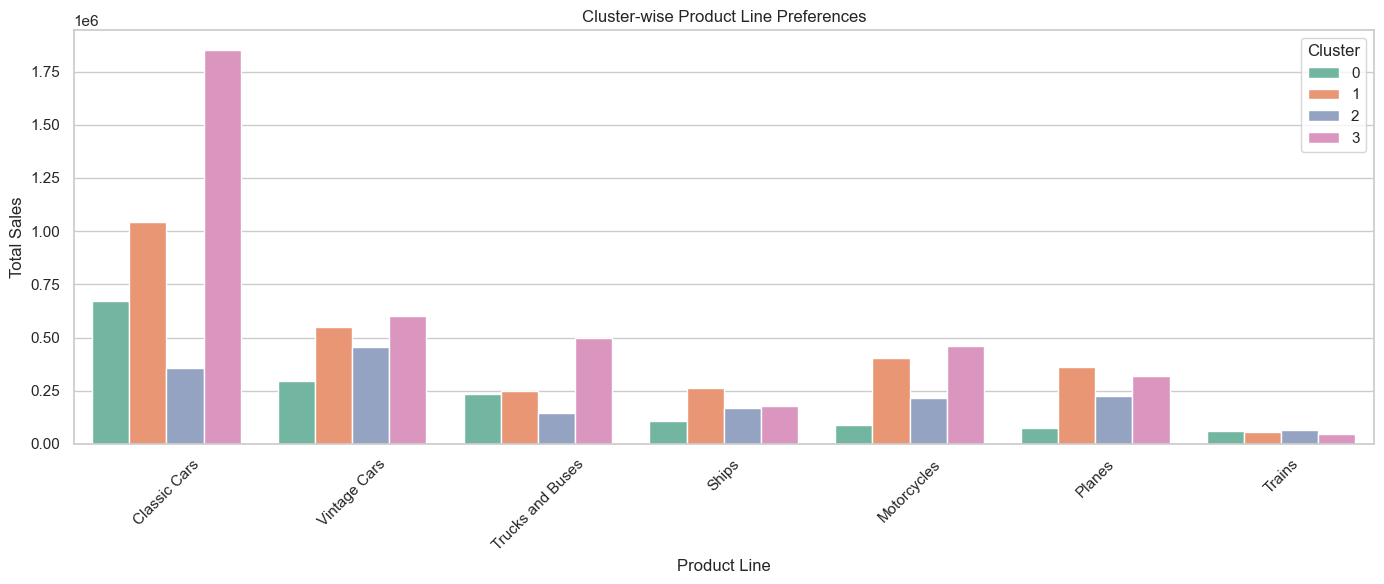

In [203]:
# Group by Segment and Product Line
product_pref = merged.groupby(['Segment', 'PRODUCTLINE']).agg(
    TotalSales=('SALES', 'sum'),
    AvgSales=('SALES', 'mean'),
    OrderCount=('ORDERNUMBER', 'nunique')
).reset_index()

# Sort by Segment and TotalSales descending
product_pref = product_pref.sort_values(['Segment', 'TotalSales'], ascending=[True, False])

# 📊 Plot: Product Preference per Cluster
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.barplot(
    data=product_pref,
    x='PRODUCTLINE', y='TotalSales', hue='Segment',
    palette='Set2'
)
plt.title('Cluster-wise Product Line Preferences')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [82]:
print("\n📊 Cluster Summary:\n")
print(summary)


📊 Cluster Summary:

         Recency  Frequency   Monetary    SALES  QUANTITYORDERED  PRICEEACH  \
Segment                                                                       
0           1.78      22.48  811742.62  3598.83            35.86      83.44   
1         158.17       3.28  113494.66  3989.36            36.98      90.06   
2         163.76       3.27  115259.97  1954.66            30.87      64.95   
3         174.02       3.15  111598.95  4747.52            37.27      96.86   

           MSRP   PRODUCTLINE TERRITORY DEALSIZE  
Segment                                           
0        100.06  Classic Cars      EMEA   Medium  
1        108.68  Classic Cars      EMEA   Medium  
2         68.94  Vintage Cars      EMEA    Small  
3        125.83  Classic Cars      EMEA   Medium  


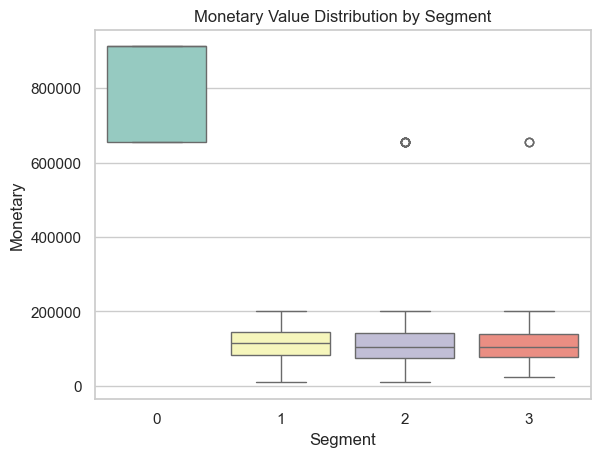

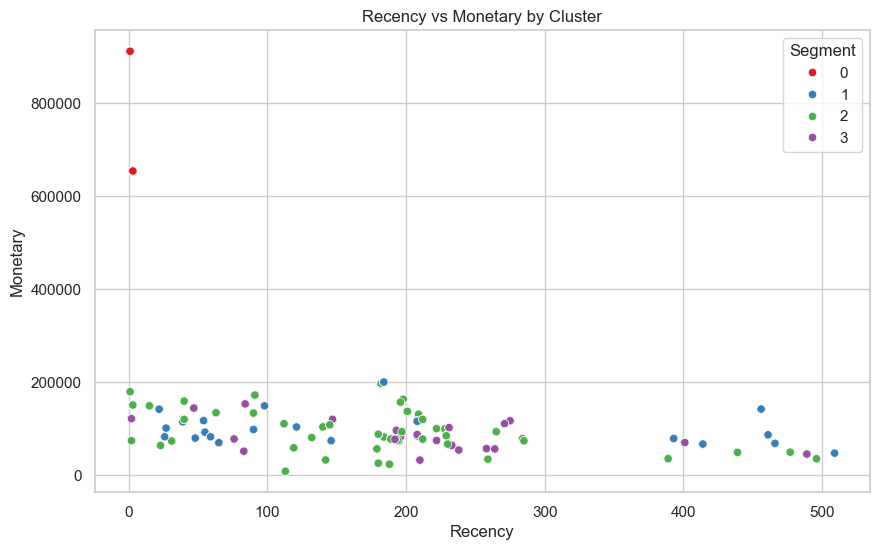

In [205]:
# 13. Visualize clusters

sns.boxplot(data=merged, x='Segment', y='Monetary', palette='Set3')
plt.title('Monetary Value Distribution by Segment')
plt.show()

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='Recency', y='Monetary', hue='Segment', palette='Set1')
plt.title('Recency vs Monetary by Cluster')
fig.savefig("cluster.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Cluster Naming, Analysis & Strategic Recommendations

### Segment 0 – Loyal High-Value Buyers
- Recency: 1.78 (recent purchases)
- Frequency: 22.48 (very frequent)
- Monetary: $811,743 (highest spenders)
- Product Preference: Classic Cars
- Deal Size: Medium
- Territory: EMEA

Insights:
- This is your most engaged and valuable customer group.
- They buy often, spend significantly, and have recently purchased.

Recommendations:
- Loyalty programs: Offer early access to products or exclusive deals.
- Upsell opportunities: Introduce premium or limited-edition products.
- Personalized marketing to retain and grow this customer segment.

### Segment 1 – Steady Mid-Tier Customers
- Recency: 158.17 (not recent)
- Frequency: 3.28
- Monetary: $113,495
- Sales Per Order: $3,989
- Product Preference: Classic Cars
- Deal Size: Medium

Insights:
- Reliable, mid-value buyers with some drop in recent activity.

Recommendations:
- Reactivation campaigns: Email reminders, discounts on favorite products.
- Surveys to understand their drop-off and improve engagement.

### Segment 2 – Low-Value Infrequent Buyers
- Recency: 163.76 (not recent)
- Frequency: 3.27
- Monetary: $115,260
- Lowest MSRP and price
- Product Preference: Vintage Cars
- Deal Size: Small

Insights:
- Price-sensitive, less engaged, and buy low-ticket items.

Recommendations:
- Bundle deals or value offers to increase transaction size.
- Targeted promotions on Vintage product line.
- Consider as a potential growth segment with proper nurturing.

### Segment 3 – Inactive Big Ticket Buyers
- Recency: 174.02 (least recent)
- Frequency: 3.15
- Monetary: $111,599
- Highest MSRP and PriceEach
- Product Preference: Classic Cars
- Deal Size: Medium

Insights:
- Previously high spenders, but currently churned.
- Prefer expensive products but no recent activity.

Recommendations:
- Win-back campaigns: Exclusive discount on luxury or new arrivals.
- Customer service follow-up: Understand churn reasons.
- Target as potential high-value customers if reactivated.

🚀 How These Insights Help Improve Sales Outcomes
Strategic Benefit	Impact
🎯 Segmentation-based targeting	Helps personalize offers and messaging, increasing conversion rates.
🤝 Customer retention	Engaging loyal and churned segments separately ensures better retention strategy.
📈 Revenue growth	By upselling to loyal buyers and increasing order value of low spenders.
💬 Informed product focus	Aligning marketing with product lines preferred by profitable segments (e.g., Classic Cars).
📊 Marketing efficiency	Reduced costs by allocating budgets toward segments with higher ROI potential.

🔵 Segment 0 – Loyal High-Value Buyers (2 Customers)
Baseline Monetary Value per Customer: $811,743

Total Revenue from Segment: ≈ $1.62M

Expected Uplift: Let’s say 10% increase via upselling and loyalty programs

Revenue Impact:
> $1.62M × 10% = $162,000

✅ Small group, but huge individual value — focus on retention.



🟢 Segment 1 – Steady Mid-Tier Customers (76 Customers)
Average Monetary per Customer: $113,495

Total Revenue: 76 × $113,495 = $8.63M

Expected Uplift: 15% via reactivation and personalized campaigns

Revenue Impact:
> $8.63M × 15% = $1.29M

✅ Large group with stable value — nurture to grow.



🟡 Segment 2 – Low-Value Infrequent Buyers (91 Customers)
Average Monetary: $115,260

Total Revenue: ≈ $10.5M

Expected Uplift: 5–7% with bundling and value promotions

Revenue Impact (7%):
> $10.5M × 7% = $735,000

🟡 Price-sensitive, but scalable with volume strategies.



🔴 Segment 3 – Inactive Big Ticket Buyers (83 Customers)
Average Monetary: $111,599

Total Revenue: ≈ $9.27M

Reactivation Target: Even 20% reactivation rate with a 10% upsell

Uplift:
> 83 × 20% × $111,599 × 10% = $185,718

🔴 High-potential churned group. Worth targeting to reactivate.

📈 Total Estimated Revenue Impact Summary
Segment	Strategy	Potential Revenue Uplift
0	Loyalty & Upsell	$162,000
1	Personalized Reactivation	$1,290,000
2	Bundle/Value Deals	$735,000
3	Win-back Campaigns (20% target)	$185,718
Total		$2.37M+



💡 Business Value
These numbers justify marketing investments in CRM, segmentation-based email campaigns, and retention strategies.

They prioritize segments:

Segment 1 and 2 for volume and consistent revenue

Segment 0 for high-value nurturing

Segment 3 for win-back opportunities



In [84]:
cluster_counts = merged.groupby('Segment')['CUSTOMERNAME'].nunique().reset_index()
cluster_counts.columns = ['Segment', 'CustomerCount']
print(cluster_counts)

   Segment  CustomerCount
0        0              2
1        1             76
2        2             91
3        3             83


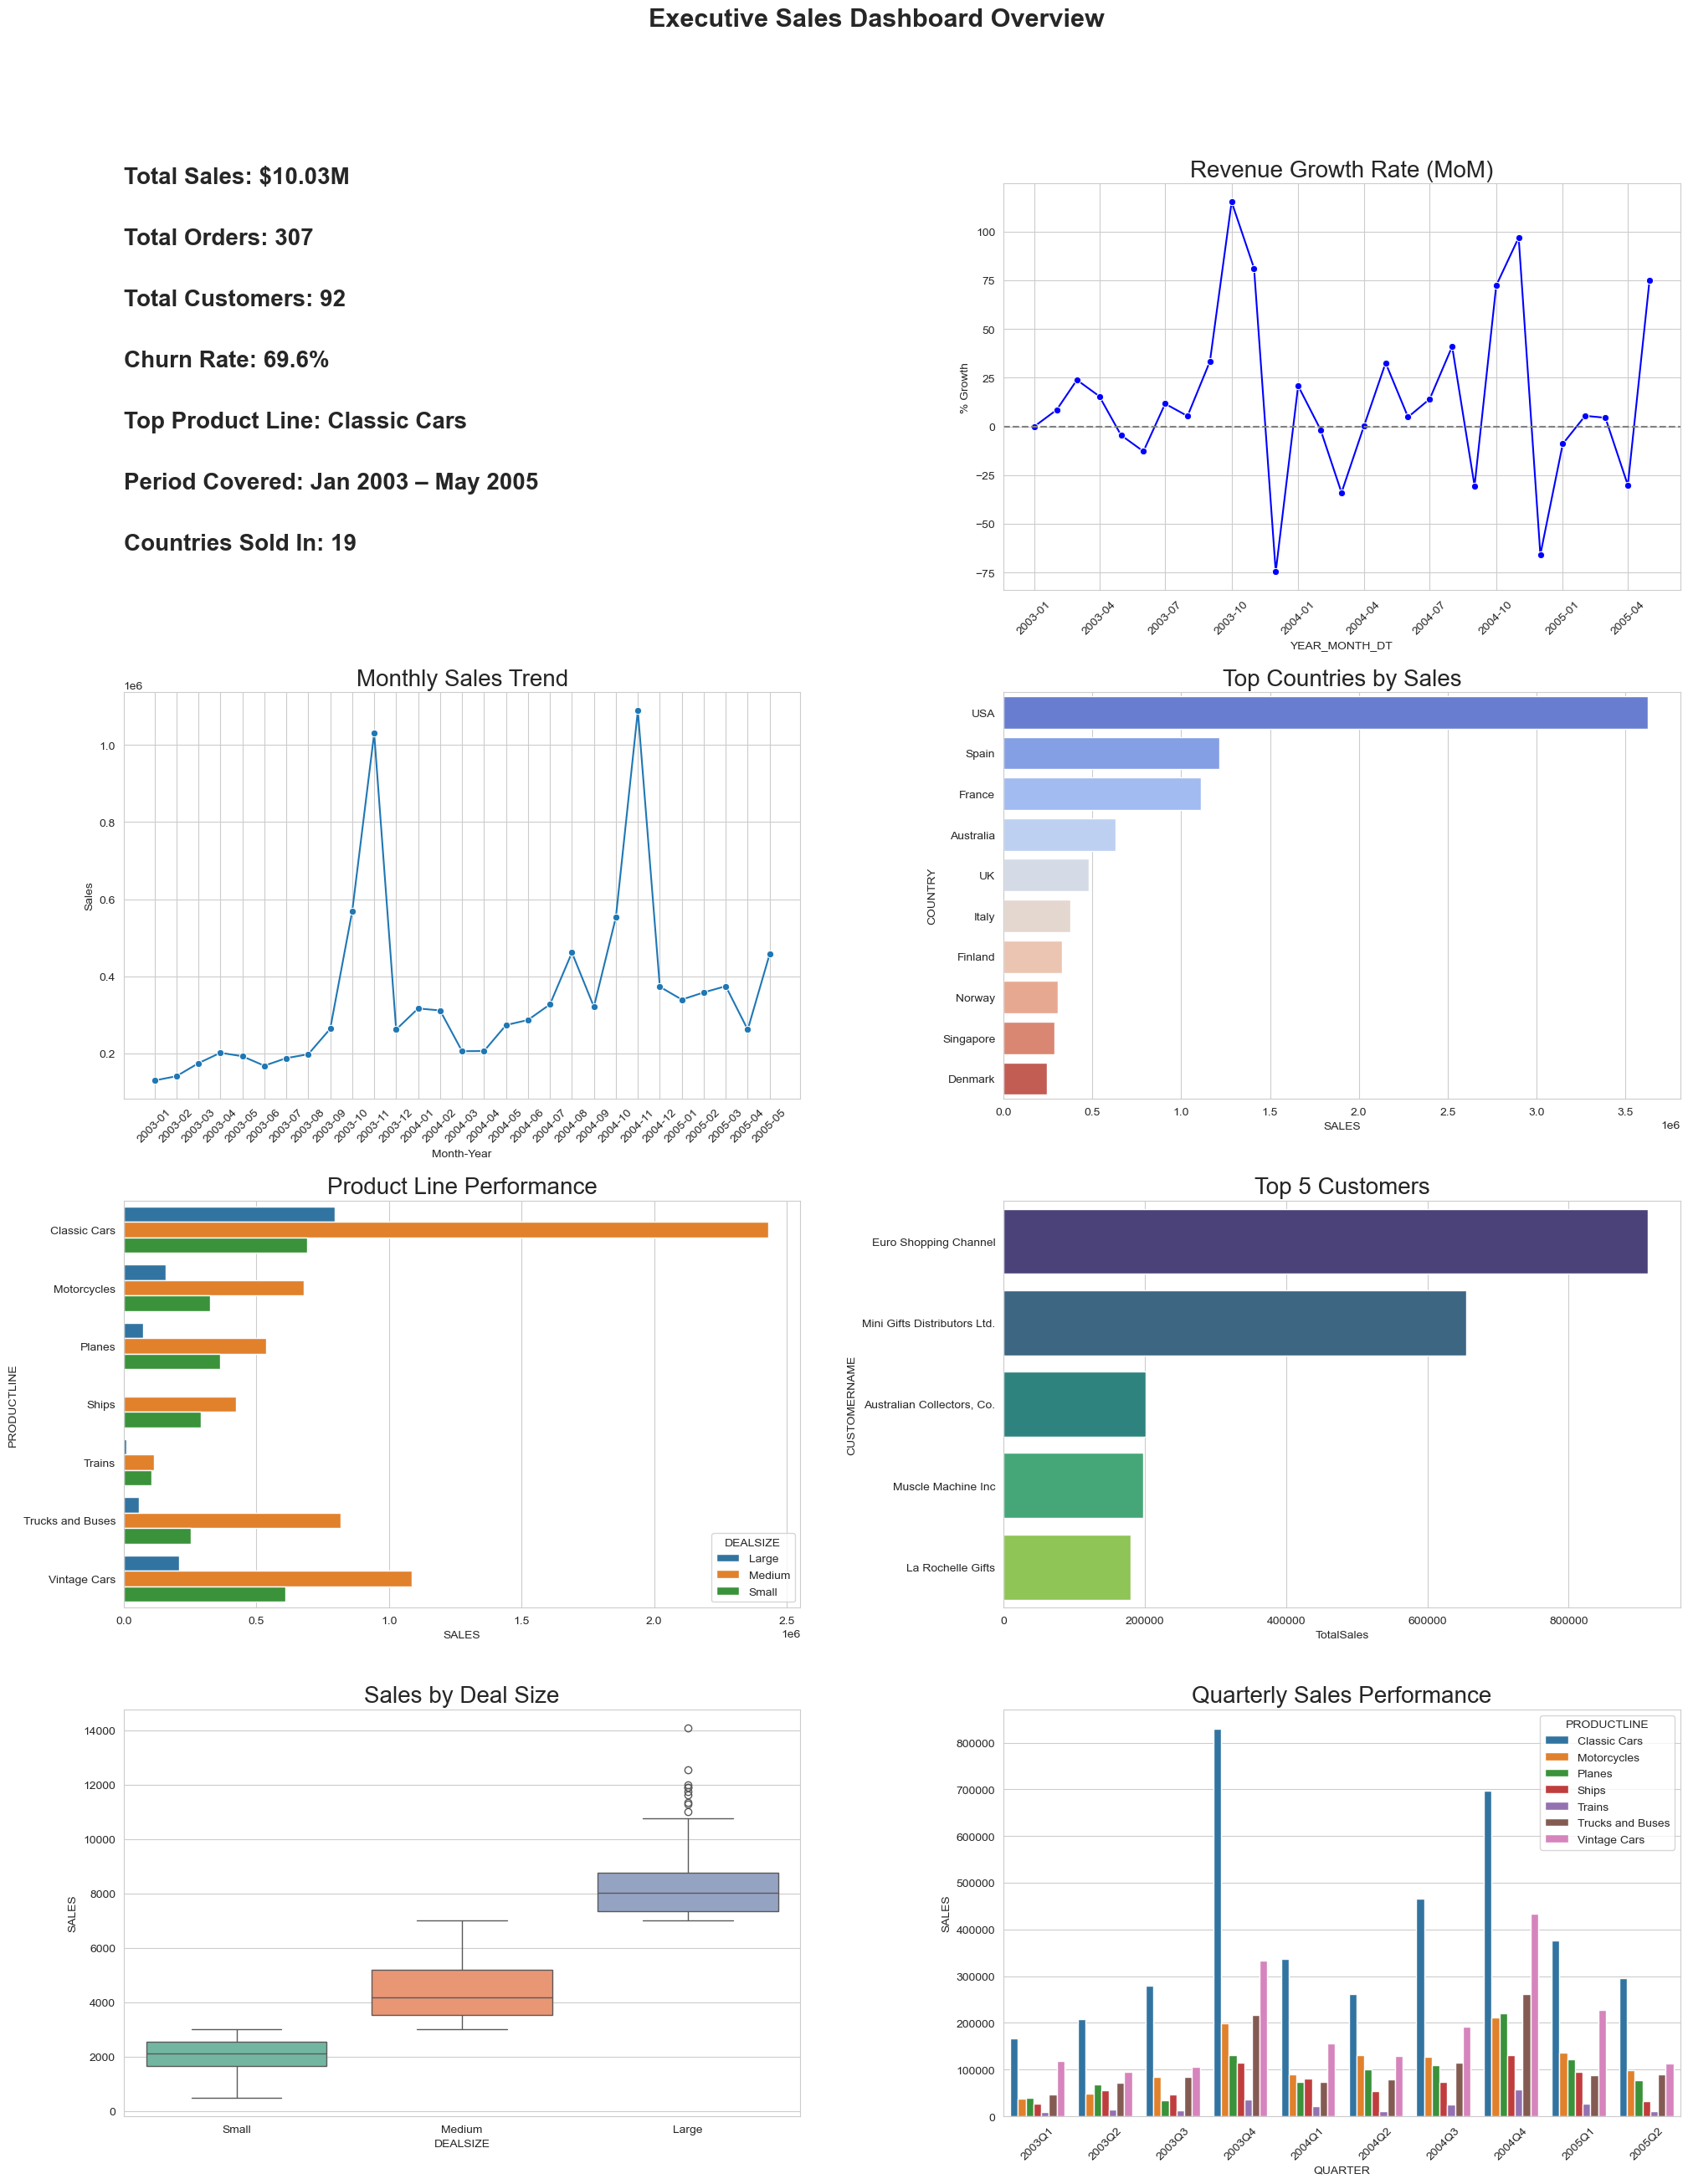

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Sample data pre-processing (assuming already defined)
sales_data['YEAR_MONTH'] = sales_data['ORDERDATE'].dt.to_period('M').astype(str)
sales_data['YEAR_MONTH_DT'] = sales_data['ORDERDATE'].dt.to_period('M').dt.to_timestamp()
sales_data['CUSTOMER_ID'] = sales_data['CUSTOMERNAME']

# === KPI Calculations ===
total_sales = sales_data['SALES'].sum() / 1_000_000  # in millions
total_orders = sales_data['ORDERNUMBER'].nunique()
total_customers = sales_data['CUSTOMER_ID'].nunique()
aov = sales_data['SALES'].sum() / total_orders
monthly_sales = sales_data.groupby('YEAR_MONTH_DT')['SALES'].sum().reset_index()
monthly_sales['MoM_Growth'] = monthly_sales['SALES'].pct_change().fillna(0) * 100
last_order = sales_data.groupby('CUSTOMER_ID')['ORDERDATE'].max()
cutoff_date = sales_data['ORDERDATE'].max() - pd.Timedelta(days=90)
churned_customers = (last_order < cutoff_date).sum()
churn_rate = churned_customers / total_customers * 100

# Assumed already calculated:
# countries, date_range, top_product_line

# === Create Combined Dashboard ===
fig = plt.figure(figsize=(24, 30))
gs = GridSpec(4, 2, figure=fig, hspace=0.25, wspace=0.3)  # 4 rows x 2 columns

# --- Section 1: KPI Cards + Revenue Growth ---
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis("off")
kpis = [
    f"Total Sales: ${total_sales:.2f}M",
    f"Total Orders: {total_orders}",
    f"Total Customers: {total_customers}",
    f"Churn Rate: {churn_rate:.1f}%",
    f"Top Product Line: {top_product_line}",
    f"Period Covered: {date_range}",
    f"Countries Sold In: {countries}"
]
for i, kpi in enumerate(kpis):
    ax0.text(0, 1 - i*0.15, kpi, fontsize=20, fontweight="bold")

ax1 = fig.add_subplot(gs[0, 1])
sns.lineplot(data=monthly_sales, x="YEAR_MONTH_DT", y="MoM_Growth", marker='o', color='blue', ax=ax1)
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_title("Revenue Growth Rate (MoM)", fontsize=20)
ax1.set_ylabel("% Growth")
ax1.tick_params(axis='x', rotation=45)

# --- Section 2 ---
# Monthly Sales Trend
monthly_sales = sales_data.groupby("YEAR_MONTH")["SALES"].sum().reset_index()
ax2 = fig.add_subplot(gs[1, 0])
sns.lineplot(data=monthly_sales, x="YEAR_MONTH", y="SALES", marker="o", ax=ax2)
ax2.set_title("Monthly Sales Trend", fontsize=20)
ax2.set_xlabel("Month-Year")
ax2.set_ylabel("Sales")
ax2.tick_params(axis='x', rotation=45)

# Top Countries
country_sales = sales_data.groupby("COUNTRY")["SALES"].sum().reset_index()
top_countries = country_sales.sort_values(by="SALES", ascending=False).head(10)
ax3 = fig.add_subplot(gs[1, 1])
sns.barplot(data=top_countries, x="SALES", y="COUNTRY", palette="coolwarm", ax=ax3)
ax3.set_title("Top Countries by Sales", fontsize=20)

# Product Line Performance
product_line_sales = sales_data.groupby(["PRODUCTLINE", "DEALSIZE"])["SALES"].sum().reset_index()
ax4 = fig.add_subplot(gs[2, 0])
sns.barplot(data=product_line_sales, x="SALES", y="PRODUCTLINE", hue="DEALSIZE", ax=ax4)
ax4.set_title("Product Line Performance", fontsize=20)

# Top 5 Customers
top_customers = sales_data.groupby(["CUSTOMERNAME", "COUNTRY"]).agg(
    TotalSales=('SALES', 'sum'),
    AvgOrderValue=('SALES', 'mean')
).sort_values(by="TotalSales", ascending=False).head(5).reset_index()
ax5 = fig.add_subplot(gs[2, 1])
sns.barplot(data=top_customers, x="TotalSales", y="CUSTOMERNAME", palette="viridis", ax=ax5)
ax5.set_title("Top 5 Customers", fontsize=20)

# Sales by Deal Size
ax6 = fig.add_subplot(gs[3, 0])
sns.boxplot(data=sales_data, x="DEALSIZE", y="SALES", palette="Set2", ax=ax6)
ax6.set_title("Sales by Deal Size", fontsize=20)

# Quarterly Sales
quarterly_sales = sales_data.groupby(["QUARTER", "PRODUCTLINE"])["SALES"].sum().reset_index()
ax7 = fig.add_subplot(gs[3, 1])
sns.barplot(data=quarterly_sales, x="QUARTER", y="SALES", hue="PRODUCTLINE", ax=ax7)
ax7.set_title("Quarterly Sales Performance", fontsize=20)
ax7.tick_params(axis='x', rotation=45)

# === Final Touches ===
fig.suptitle("Executive Sales Dashboard Overview", fontsize=22, fontweight="bold", y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# === Save the whole dashboard as image ===
fig.savefig("full_sales_dashboard.jpg", dpi=300, bbox_inches='tight')
fig.savefig("full_sales_dashboard.pdf", bbox_inches='tight')

plt.show()


In [31]:
import warnings
warnings.filterwarnings('ignore')

In [118]:
fig.savefig("sales_dashboard.jpg", dpi=300, bbox_inches='tight')

# Save as PDF
fig.savefig("sales_dashboard.pdf", bbox_inches='tight')